In [13]:
import muon as mu
import scanpy as sc
import seaborn as sns
from scipy.stats import median_abs_deviation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
adata = sc.read_h5ad('../data/rna_subset.h5ad')

# QC (already performed for sea-ad)

In [50]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [51]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
adata

AnnData object with n_obs × n_vars = 3129 × 36412
    obs: 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'is_primary_data', 'Neurotypical reference', 'Class', 'Subclass', 'Supertype', 'Age at death', 'Years of education', 'Cognitive status', 'ADNC', 'Braak stage', 'Thal phase', 'CERAD score', 'APOE4 status', 'Lewy body disease pathology', 'LATE-NC stage', 'Microinfarct pathology', 'Specimen ID', 'donor_id', 'PMI', 'Number of UMIs', 'Genes detected', 'Fraction mitochrondrial UMIs', 'suspension_type', 'development_stage_ontology_term_id', 'Continuous Pseudo-progression Score', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_co

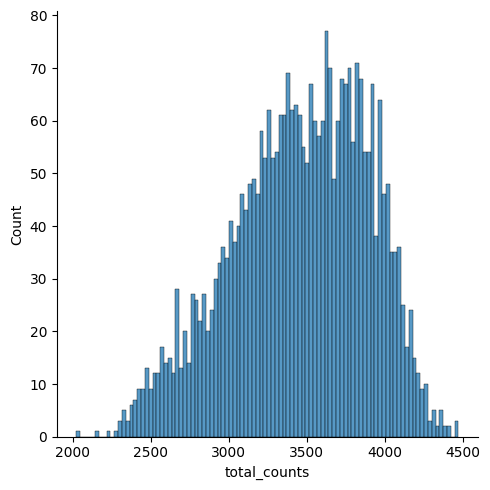

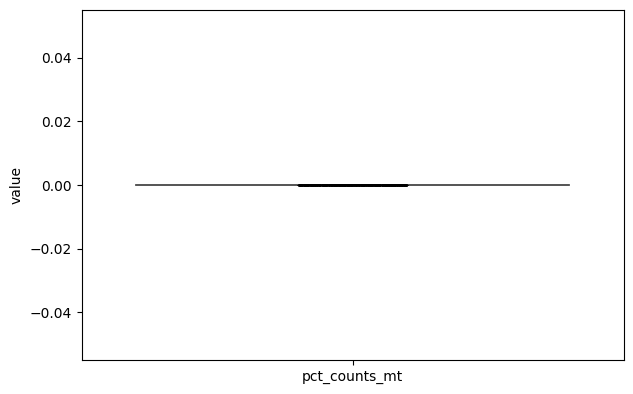

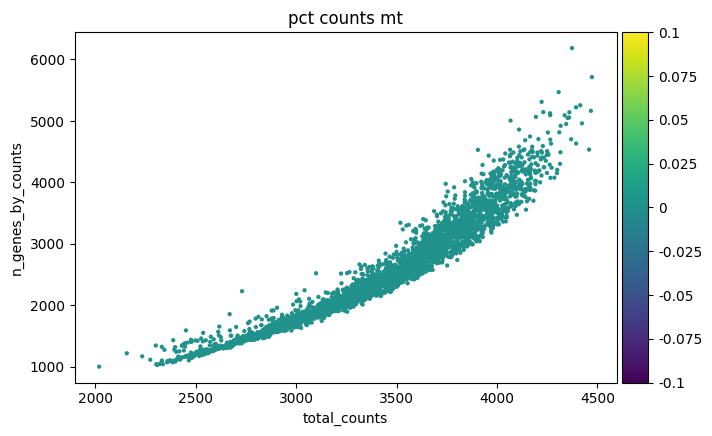

In [52]:
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
# sc.pl.violin(adata, 'total_counts')
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [53]:
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

In [54]:
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
)

adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (
    adata.obs["pct_counts_mt"] > 8
)
adata.obs.mt_outlier.value_counts()

print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

Total number of cells: 3129
Number of cells after filtering of low quality cells: 3092


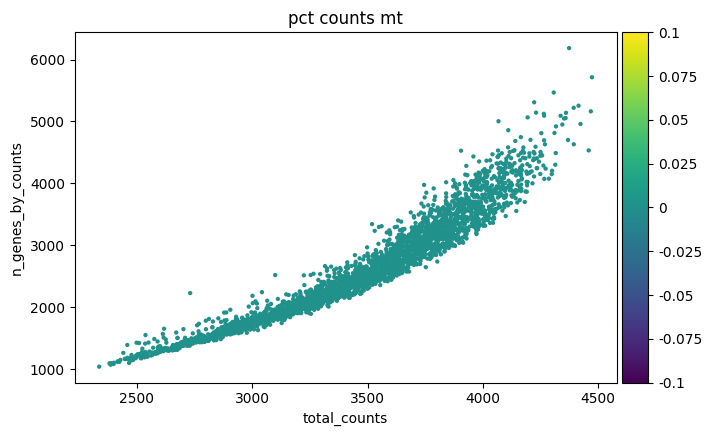

In [55]:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

# normalisation (already done for sea-ad)

In [56]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

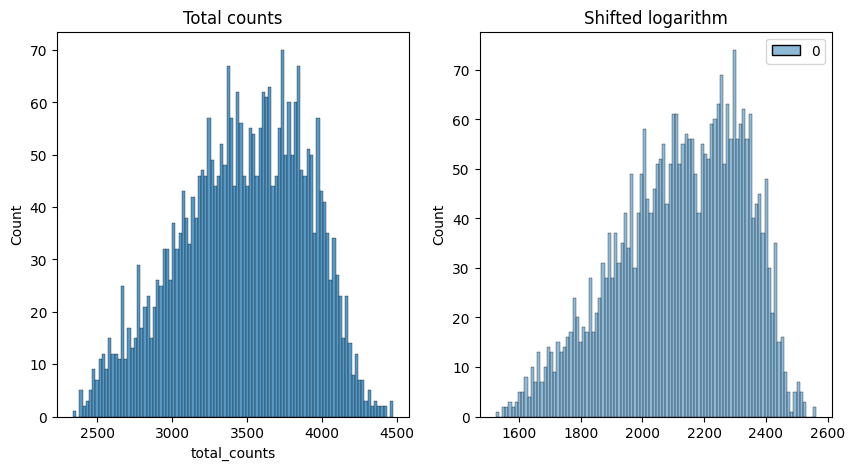

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(axis = 1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

# select HVGs

In [23]:
hvgs = sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=2000, inplace=False)
hvgs

/opt/anaconda3/envs/sc_analysis/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


,means,variances,gene_name,highly_variable_rank,variances_norm,highly_variable
ENSG00000000003,0.001097,0.001000,ENSG00000000003,NaN,0.887200,False
ENSG00000000005,0.000000,0.000000,ENSG00000000005,NaN,0.000000,False
ENSG00000000419,0.200018,0.192000,ENSG00000000419,NaN,0.942015,False
ENSG00000000457,0.162566,0.166525,ENSG00000000457,NaN,0.992852,False
ENSG00000000460,0.263253,0.280558,ENSG00000000460,NaN,1.068936,False
...,...,...,...,...,...,...
ENSG00000288701,1.085060,0.593632,ENSG00000288701,NaN,0.856000,False
ENSG00000288702,0.000000,0.000000,ENSG00000288702,NaN,0.000000,False
ENSG00000288705,0.000000,0.000000,ENSG00000288705,NaN,0.000000,False
ENSG00000288709,0.000000,0.000000,ENSG00000288709,NaN,0.000000,False


In [58]:
adata.var["highly_variable"] = hvgs["highly_variable"]
adata_hvg = adata[:, adata.var['highly_variable']].copy()

In [59]:
adata_hvg

AnnData object with n_obs × n_vars = 3092 × 2000
    obs: 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'is_primary_data', 'Neurotypical reference', 'Class', 'Subclass', 'Supertype', 'Age at death', 'Years of education', 'Cognitive status', 'ADNC', 'Braak stage', 'Thal phase', 'CERAD score', 'APOE4 status', 'Lewy body disease pathology', 'LATE-NC stage', 'Microinfarct pathology', 'Specimen ID', 'donor_id', 'PMI', 'Number of UMIs', 'Genes detected', 'Fraction mitochrondrial UMIs', 'suspension_type', 'development_stage_ontology_term_id', 'Continuous Pseudo-progression Score', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_cou

In [69]:
adata_hvg.obs["Braak stage"]

exp_component_name
GGTGAGGTCAATAGCC-L8XR_210729_01_E09-1122543707     Braak VI
CTAGGACGTTAGTTGG-L8XR_211007_02_F03-1135448413    Braak III
GGTCCTGCACACTAAT-L8XR_210812_01_E11-1126220036      Braak V
AATTAGCGTTGGCCGA-L8XR_211021_02_G06-1138433804     Braak IV
AGTCAGGCATGAATAG-L8XR_210715_01_A12-1121939868     Braak IV
                                                    ...    
ATCAAGCTCCTTCGTA-L8XR_210812_01_A12-1124987483     Braak IV
ACAACAGAGGGTCTAT-L8XR_211014_02_H05-1136687627      Braak V
TTGGGCCAGACTTATG-L8XR_210812_01_A12-1124987483     Braak IV
GAGGAGGCATGCTATG-L8XR_210902_02_D08-1131257170      Braak V
GCGTAACGTTCACCAT-L8XR_210729_01_D09-1124629224     Braak VI
Name: Braak stage, Length: 3092, dtype: category
Categories (5, object): ['Braak 0', 'Braak III', 'Braak IV', 'Braak V', 'Braak VI']

In [79]:
sc.pp.neighbors(adata_hvg, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata_hvg)

In [ ]:
for i in adata.obs:
    sc.pl.umap(adata_hvg, color= i, show=True)

In [82]:
adata_hvg

AnnData object with n_obs × n_vars = 3092 × 2000
    obs: 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'is_primary_data', 'Neurotypical reference', 'Class', 'Subclass', 'Supertype', 'Age at death', 'Years of education', 'Cognitive status', 'ADNC', 'Braak stage', 'Thal phase', 'CERAD score', 'APOE4 status', 'Lewy body disease pathology', 'LATE-NC stage', 'Microinfarct pathology', 'Specimen ID', 'donor_id', 'PMI', 'Number of UMIs', 'Genes detected', 'Fraction mitochrondrial UMIs', 'suspension_type', 'development_stage_ontology_term_id', 'Continuous Pseudo-progression Score', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_cou